In [1]:
import sys
sys.path.append("..")
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy

### State preparation with 1 ancilla and 2 excitations on a total of 35 qubits

In [2]:
def prep_psi_0(qc: QuantumCircuit):
    qc.cx(34, 4)
    qc.cx(34, 21)
    return qc


def prep_psi_0_by_0(qc: QuantumCircuit):
    qc.cx(34, 4, ctrl_state="0")
    qc.cx(34, 21, ctrl_state="0")
    return qc

### Test if state prep works as expected

In [3]:
from qiskit_aer import StatevectorSimulator
from qiskit_aer.primitives import SamplerV2

# sv = StatevectorSimulator()
sampler = SamplerV2(options={"backend_options": {"method": "matrix_product_state"}})
qc = QuantumCircuit(35)
qc.h(34)
qc = prep_psi_0(qc)
qc.measure_all()

job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'00000000000000000000000000000000000': 524,
 '10000000000001000000000000000010000': 500}

In [26]:
qc = QuantumCircuit(35)
qc.h(34)
qc = prep_psi_0(qc)
qc = prep_psi_0_by_0(qc)
qc.measure_all()
job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'00000000000001000000000000000010000': 516,
 '10000000000001000000000000000010000': 508}

## Hardware experiments

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.backend("ibm_torino")

In [9]:
from qiskit.quantum_info import Pauli

def Heisenberg(J, n, ent_map, h=0, mag=False):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    if mag:
        for i in range(n):
            z_string = Pauli("I"*n)
            z_string[i] = "Z"
            H+= h*SparsePauliOp(z_string)        
    return H.chop()

In [ ]:
from qiskit.transpiler import generate_preset_pass_manager


t_steps = 8
num_qubits = 34
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40
synth = LieTrotter(reps=1)

qubit_subset = (
    list(range(42, 48))
    + [35]
    + list(range(25, 30))
    + [36, 48, 49, 50, 54]
    + list(range(61, 66))
    + list(range(66, 70))
    + [56, 73, 82, 83, 84, 85, 86, 74]
)
# remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
# rev_map = {val: key for key, val in remap.items()}


cm = backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}
# ent_dec = [(rev_map[i], rev_map[j]) for i, j in edge_list]


def Heisenberg(J, n, ent_map, h=0, mag=None):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    if mag == None:
        for i in range(n):
            z_string = "I"*n
            z_string[i] = "Z"
            H+= h*SparsePauliOp(z_string)        
    return H.chop()


H = Heisenberg(1, num_qubits, edge_list)

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(num_qubits)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(num_qubits).compose(qc_temp)

# time_evol=PauliEvolutionGate(H,time=delta_t,synthesis=synth)
real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * 34, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * 34, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy()

init_layout = qubit_subset + [55]  # ancilla at qubit 55 on torino
pm = generate_preset_pass_manager(
    backend=backend, optimization_level=3, initial_layout=init_layout
)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]

print(
    f"Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)

# Circuit execution

## Run as individual jobs to allow more shots

In [91]:
from qiskit_ibm_runtime import EstimatorV2, Batch, EstimatorOptions

estimator = EstimatorV2(mode=backend)
estimator.options.default_shots = 800000  # Try going upto 1000000
estimator.options.resilience_level = 2
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = "XY4"
estimator.options.resilience.zne.noise_factors = (1, 1.3, 1.6)  # use fractional folding
estimator.options.resilience.zne.extrapolator = (
    "linear"  # exponential fit showed high std's, use this instead.
)
# estimator.options.experimental = {"execution_path": "gen3-turbo"}

est_jobs = []
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circ = circs[i][j]
        else:
            circ = circs[j][i]
        est_jobs.append(
            estimator.run(
                [
                    (
                        circ,
                        [
                            real_obs_H.apply_layout(circ.layout),
                            imag_obs_H.apply_layout(circ.layout),
                            real_obs_S.apply_layout(circ.layout),
                            imag_obs_S.apply_layout(circ.layout),
                        ],
                    )
                ]
            )
        )

In [93]:
job_results = [job.result() for job in est_jobs]
print([job for job in est_jobs if job.errored()])  # check if any of the jobs errored.

[]


In [94]:
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
idx = 0
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            H_tilde[i, j] = (
                job_results[idx][0].data.evs[0] + 1j * job_results[idx][0].data.evs[1]
            )
            S_tilde[i, j] = (
                job_results[idx][0].data.evs[2] + 1j * job_results[idx][0].data.evs[3]
            )
        else:
            H_tilde[i, j] = np.conj(H_tilde[j, i])
            S_tilde[i, j] = np.conj(S_tilde[j, i])
        idx += 1

In [96]:
from sympy import Matrix

Matrix(S_tilde)

Matrix([
[   0.959575828823403 - 0.00857742061309832*I,    0.853644935323086 + 0.418176280511675*I,     0.322306270096692 + 0.53406134050212*I,  -0.0604873934886156 + 0.527410358098642*I, -0.149658109243103 + 0.232048269271491*I,  -0.112897581585932 + 0.0838076172071938*I, -0.0641644224364905 + 0.0256418911729134*I, -0.0145032378661772 - 0.000942306597573612*I],
[     0.853644935323086 - 0.418176280511675*I,    1.02470389252582 - 0.0417487614520974*I,     0.80975080872664 + 0.538049079234427*I,    0.248895925146419 + 0.721160664558261*I, 0.0114287671699229 + 0.586514652907093*I,    -0.176416485190081 + 0.27465530645776*I,  -0.131920433355231 + 0.0893072341366739*I,   -0.0626920226119782 + 0.0090969723532626*I],
[      0.322306270096692 - 0.53406134050212*I,     0.80975080872664 - 0.538049079234427*I,   1.05075628272806 + 0.00340987329899902*I,    0.818956670308778 + 0.416913481429479*I,  0.238775000195693 + 0.611516013778219*I, -0.00986057924252739 + 0.540606927700259*I,   -0.157005240

In [97]:
Matrix(H_tilde)

Matrix([
[   26.814284896499 - 0.265352296555781*I,    18.6785769981071 + 8.69132940707286*I,   7.21646854457641 + 8.61683138017184*I,  1.56586756707595 + 8.95790207563456*I, -0.372146007313353 + 3.80935237734334*I,  -0.472579441313158 + 2.08885924608904*I, -0.396913480737988 + 1.01822023613189*I, -0.114974692104677 + 0.390386914780405*I],
[   18.6785769981071 - 8.69132940707286*I,    25.7611186973126 - 1.27309880717613*I,     17.4834792691221 + 10.44377463844*I,  5.61565909972372 + 11.3561394551261*I,   2.69291255098648 + 7.47667364009326*I, -0.0260345473844147 + 4.30863422848747*I,  -0.65310493955123 + 1.75490842836544*I, -0.579642036234153 + 0.886440530792838*I],
[   7.21646854457641 - 8.61683138017184*I,      17.4834792691221 - 10.44377463844*I,  22.2312571856084 - 0.437184827517077*I,  15.2592186376797 + 7.03015639314767*I,   5.07758924771668 + 7.77065616584359*I,     2.3614604774124 + 6.22225712970981*I, -0.210220747753656 + 2.68298083999676*I,   -0.667239429035696 + 1.8975700554

In [7]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    # make truncated matrix whose rows are eigenvectors of S with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T
    print(len(truncated_eigvals))
    return truncated_eigvecs


def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde)+1):
        epsilon = threshold_slope
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        # solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps
        B = V_eps.conj().T @ S_temp @ V_eps
        E, c = scipy.linalg.eig(a=A, b=B)
        idx = E.argsort()[::-1]
        eigvals = E[idx]
        eigvecs = c[:, idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:, -1])
        print(min(eigvals))

    return GSEs, ground_states, V_eps

## Run on (a noisy) simulator for comparison

In [25]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2
# from qiskit_ibm_runtime import EstimatorV2
from qiskit_aer.noise import NoiseModel
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeTorino
from tqdm.notebook import tqdm


t_steps = 8
n_qubits = 34  # number of data qubits
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde_sim_noisy_pb30 = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy_pb30 = np.zeros([t_steps, t_steps], dtype=complex)

delta_t = np.pi / 30
synth = LieTrotter(reps=1)
num_shots = 800000

H = Heisenberg(1, n_qubits, edge_list)

backend = service.backend("ibm_torino")

basis_gates = backend.basis_gates


# initialize noisy simulator

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state"},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)

# pm = generate_preset_pass_manager(backend=sim_backend, optimization_level=3)
# Rxyz_circ = QuantumCircuit(2)
# Rxyz_circ.rxx(2 * delta_t, 0, 1)
# Rxyz_circ.ryy(2 * delta_t, 0, 1)
# Rxyz_circ.rzz(2 * delta_t, 0, 1)
# Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
# qc_temp = QuantumCircuit(n_qubits)
# for edge in edge_list:
#     qc_temp.append(Rxyz_instr, edge)
# time_evol = QuantumCircuit(n_qubits).compose(qc_temp)


time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * n_qubits, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * n_qubits, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = transpile(qc.copy().decompose(reps=1), basis_gates=basis_gates)



with tqdm(total=t_steps*t_steps) as pbar:
    for i in range(t_steps):
        for j in range(t_steps):
            if circuits[i][j] is not None:
                circ = circuits[i][j]
                layout = circ.layout
                obs=[real_obs_H, imag_obs_H,
                          real_obs_S, imag_obs_S]
                sim_job = simulator.run(
                [
                    (
                        circ, obs
                    )
                ]
                )
                H_tilde_sim_noisy_pb30[i, j] = (
                    sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy_pb30[i, j] = (
                    sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
                )
            else:
                circ = circuits[j][i]
                layout = circ.layout
                obs=[real_obs_H.apply_layout(layout), imag_obs_H.apply_layout(layout),
                          real_obs_S.apply_layout(layout), imag_obs_S.apply_layout(layout)]
                sim_job = simulator.run(
                [
                    (
                        circ,obs
                    )
                ]
                )
                H_tilde_sim_noisy_pb30[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy_pb30[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
                )
            pbar.update(1)

        

  0%|          | 0/64 [00:00<?, ?it/s]

In [26]:
delta_t = np.pi / 20
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde_sim_noisy_pb20 = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy_pb20 = np.zeros([t_steps, t_steps], dtype=complex)


time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = transpile(qc.copy().decompose(reps=1), basis_gates=basis_gates)



with tqdm(total=t_steps*t_steps) as pbar:
    for i in range(t_steps):
        for j in range(t_steps):
            if circuits[i][j] is not None:
                circ = circuits[i][j]
                layout = circ.layout
                obs=[real_obs_H, imag_obs_H,
                          real_obs_S, imag_obs_S]
                sim_job = simulator.run(
                [
                    (
                        circ, obs
                    )
                ]
                )
                H_tilde_sim_noisy_pb20[i, j] = (
                    sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy_pb20[i, j] = (
                    sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
                )
            else:
                circ = circuits[j][i]
                layout = circ.layout
                obs=[real_obs_H.apply_layout(layout), imag_obs_H.apply_layout(layout),
                          real_obs_S.apply_layout(layout), imag_obs_S.apply_layout(layout)]
                sim_job = simulator.run(
                [
                    (
                        circ,obs
                    )
                ]
                )
                H_tilde_sim_noisy_pb20[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy_pb20[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
                )
            pbar.update(1)


  0%|          | 0/64 [00:00<?, ?it/s]

In [27]:

delta_t = np.pi / 10
H_tilde_sim_noisy_pb10 = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy_pb10 = np.zeros([t_steps, t_steps], dtype=complex)
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)

time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = transpile(qc.copy().decompose(reps=1), basis_gates=basis_gates)



with tqdm(total=t_steps*t_steps) as pbar:
    for i in range(t_steps):
        for j in range(t_steps):
            if circuits[i][j] is not None:
                circ = circuits[i][j]
                layout = circ.layout
                obs=[real_obs_H, imag_obs_H,
                          real_obs_S, imag_obs_S]
                sim_job = simulator.run(
                [
                    (
                        circ, obs
                    )
                ]
                )
                H_tilde_sim_noisy_pb10[i, j] = (
                    sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy_pb10[i, j] = (
                    sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
                )
            else:
                circ = circuits[j][i]
                layout = circ.layout
                obs=[real_obs_H.apply_layout(layout), imag_obs_H.apply_layout(layout),
                          real_obs_S.apply_layout(layout), imag_obs_S.apply_layout(layout)]
                sim_job = simulator.run(
                [
                    (
                        circ,obs
                    )
                ]
                )
                H_tilde_sim_noisy_pb10[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy_pb10[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
                )
            pbar.update(1)


  0%|          | 0/64 [00:00<?, ?it/s]

In [28]:
delta_t = np.pi / 40
H_tilde_sim_noisy_pb40 = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy_pb40 = np.zeros([t_steps, t_steps], dtype=complex)
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = transpile(qc.copy().decompose(reps=1), basis_gates=basis_gates)



with tqdm(total=t_steps*t_steps) as pbar:
    for i in range(t_steps):
        for j in range(t_steps):
            if circuits[i][j] is not None:
                circ = circuits[i][j]
                layout = circ.layout
                obs=[real_obs_H, imag_obs_H,
                          real_obs_S, imag_obs_S]
                sim_job = simulator.run(
                [
                    (
                        circ, obs
                    )
                ]
                )
                H_tilde_sim_noisy_pb40[i, j] = (
                    sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy_pb40[i, j] = (
                    sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
                )
            else:
                circ = circuits[j][i]
                layout = circ.layout
                obs=[real_obs_H.apply_layout(layout), imag_obs_H.apply_layout(layout),
                          real_obs_S.apply_layout(layout), imag_obs_S.apply_layout(layout)]
                sim_job = simulator.run(
                [
                    (
                        circ,obs
                    )
                ]
                )
                H_tilde_sim_noisy_pb40[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy_pb40[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
                )
            pbar.update(1)


  0%|          | 0/64 [00:00<?, ?it/s]

In [29]:
delta_t = np.pi / 11
H_tilde_sim_noisy_pb11 = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy_pb11 = np.zeros([t_steps, t_steps], dtype=complex)
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = transpile(qc.copy().decompose(reps=1), basis_gates=basis_gates)



with tqdm(total=t_steps*t_steps) as pbar:
    for i in range(t_steps):
        for j in range(t_steps):
            if circuits[i][j] is not None:
                circ = circuits[i][j]
                layout = circ.layout
                obs=[real_obs_H, imag_obs_H,
                          real_obs_S, imag_obs_S]
                sim_job = simulator.run(
                [
                    (
                        circ, obs
                    )
                ]
                )
                H_tilde_sim_noisy_pb11[i, j] = (
                    sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy_pb11[i, j] = (
                    sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
                )
            else:
                circ = circuits[j][i]
                layout = circ.layout
                obs=[real_obs_H.apply_layout(layout), imag_obs_H.apply_layout(layout),
                          real_obs_S.apply_layout(layout), imag_obs_S.apply_layout(layout)]
                sim_job = simulator.run(
                [
                    (
                        circ,obs
                    )
                ]
                )
                H_tilde_sim_noisy_pb11[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy_pb11[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
                )
            pbar.update(1)


  0%|          | 0/64 [00:00<?, ?it/s]

1
(27.958237107665568-0.013854525736312897j)
2
(25.757913710079347+0.028078992400655502j)
3
(24.343373495661396+0.08114344985854494j)
4
(23.55059388779154+0.11605669019384682j)
5
(23.09973759120489+0.1258271027351558j)
6
(22.67003333427887+0.1403689656861497j)
7
(22.304765659391943+0.12523083823747352j)
8
(22.037370818806306+0.07983072678327514j)
1
(27.978309230174872-0.02657936553252356j)
2
(25.437366779330564-0.030402378111886518j)
3
(23.903080699778826-0.07107124419651305j)
4
(23.080609418623318-0.11413251564285426j)
5
(22.688303526642233-0.0658305210950597j)
6
(22.3742294910998+0.039681010149426224j)
7
(21.844657767576226+0.22076802076793758j)
8
(21.257252711282405+0.42838761253723406j)


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

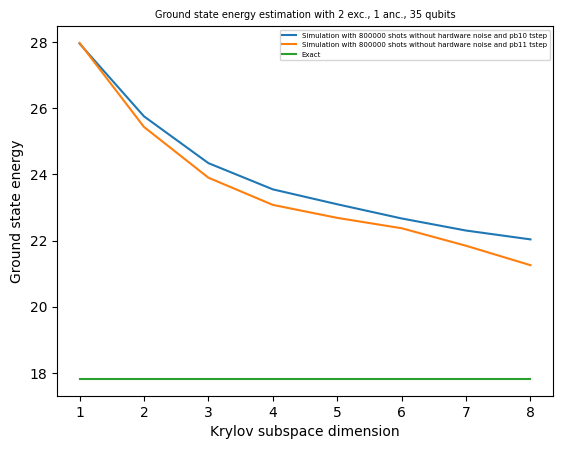

In [30]:
import matplotlib.pyplot as plt

threshold = 1e-2
#GSEs_sim_noisy_pb40, _, _ = E_vs_D(H_tilde_sim_noisy_pb40, S_tilde_sim_noisy_pb40,threshold)
# GSEs_sim_noisy_pb30, _, _ = E_vs_D(H_tilde_sim_noisy_pb30, S_tilde_sim_noisy_pb30,threshold)
# GSEs_sim_noisy_pb20, _, _ = E_vs_D(H_tilde_sim_noisy_pb20, S_tilde_sim_noisy_pb20,threshold)
GSEs_sim_noisy_pb10, g_state, _ = E_vs_D(H_tilde_sim_noisy_pb10, S_tilde_sim_noisy_pb10,threshold)
GSEs_sim_noisy_pb11, _, _ = E_vs_D(H_tilde_sim_noisy_pb11, S_tilde_sim_noisy_pb11,threshold)

# plt.plot(
#     list(range(1, t_steps + 1)),
#          GSEs_sim_noisy_pb40,
#     label=f"Simulation with {num_shots} shots without hardware noise and pb40 tstep",
# )
# plt.plot(
#     list(range(1, t_steps + 1)),
#          GSEs_sim_noisy_pb30,
#     label=f"Simulation with {num_shots} shots without hardware noise and pb30 tstep",
# )
# plt.plot(
#     list(range(1, t_steps + 1)),
#          GSEs_sim_noisy_pb20,
#     label=f"Simulation with {num_shots} shots without hardware noise and pb20 tstep",
# )
plt.plot(
    list(range(1, t_steps + 1)),
         GSEs_sim_noisy_pb10,
    label=f"Simulation with {num_shots} shots without hardware noise and pb10 tstep",
)
plt.plot(
    list(range(1, t_steps + 1)),
         GSEs_sim_noisy_pb11,
    label=f"Simulation with {num_shots} shots without hardware noise and pb11 tstep",
)
plt.plot(
    list(range(1, t_steps+1)),
    17.81817798453781 * np.ones(t_steps),
    label="Exact",
)

plt.title("Ground state energy estimation with 2 exc., 1 anc., 35 qubits", fontsize=7)
plt.legend(fontsize = 5,loc="upper right")
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")

In [31]:
g_state[-1]

array([-0.19127881+0.2437285j , -0.12152564-0.07097225j,
       -0.17585373-0.32016599j,  0.05728428-0.23555996j,
       -0.0086876 +0.21614048j,  0.30675571-0.06534069j,
       -0.09423397-0.37011609j, -0.5397719 +0.33109245j])

In [179]:
from qiskit_aer.primitives import SamplerV2


t_steps=1
delta_t = np.pi / 11
H_tilde_sim_noisy_pb11 = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy_pb11 = np.zeros([t_steps, t_steps], dtype=complex)
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)

time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

simulator = SamplerV2(default_shots=num_shots,
                      options={
        "backend_options": {"method": "matrix_product_state"}}
)
dict={}
with tqdm(total=t_steps) as pbar:
    for j in range(t_steps):
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(j):
            qc.append(time_evol, range(34))
        #qc=transpile(qc.decompose(reps=1), basis_gates=basis_gates)
        qc.measure_all()
        sim_job = simulator.run([(circ)])
        snap = sim_job.result()[0].data.meas.get_counts()
        dict[(j)] = snap
        pbar.update(1)
        

  0%|          | 0/1 [00:00<?, ?it/s]

In [180]:
dict[0]

{'00000000000100000000000100000000000': 3009,
 '00000000100000000000000000000000010': 13724,
 '00000001000000000000000100000000000': 1204,
 '00000000100000000100000000000000000': 21252,
 '10000000100000000000000100000000000': 18790,
 '11000000000000000000000000000000010': 605,
 '00000000000000000001000010000000000': 165,
 '00000000000100000100000000000000000': 3386,
 '10000000100000000000000000000000010': 13716,
 '00000000100000000000010000000000000': 4933,
 '00000000010000000000000000000000010': 342,
 '10000001000000000001000000000000000': 162,
 '00000000000000000100000000010000000': 1960,
 '00001000100000000000000000000000000': 495,
 '10000000000000100100000000000000000': 4060,
 '00000000001000000000000000001000000': 588,
 '10000000000000010100000000000000000': 2585,
 '00000000001000000000000000000000010': 3700,
 '10000100000000000000000000000010000': 1578,
 '00000000000000100000000001000000000': 280,
 '10000000100000000000000000000010000': 14869,
 '0000000010000000000000000000000010

In [72]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import Aer

# Create a simple quantum circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Save the matrix product state
#qc.save_matrix_product_state()

# Execute with the matrix_product_state method
sim = Aer.get_backend('aer_simulator_matrix_product_state')
result = sim.run(qc).result()

# Retrieve the MPS state from the result
#mps_state = result.data(0)['matrix_product_state']


## Exact diagonalisation for comparison

In [107]:
# Method from Krylov tutorial
import itertools as it
import scipy as sp
from qiskit.quantum_info import Pauli


def n_particle_gs(H_op, n_qubits, n_exc):
    """
    Find the ground state of the n particle(excitation) sector
    """
    H_x = []
    for p, coeff in H_op.to_list():
        H_x.append(set([i for i, v in enumerate(Pauli(p).x) if v]))

    H_z = []
    for p, coeff in H_op.to_list():
        H_z.append(set([i for i, v in enumerate(Pauli(p).z) if v]))

    H_c = H_op.coeffs

    n_exc = n_exc
    sub_dimn = int(sp.special.comb(n_qubits, n_exc))
    print("n_exc", n_exc, ", subspace dimension", sub_dimn)

    n_particle_H = np.zeros((sub_dimn, sub_dimn), dtype=complex)

    sparse_vecs = [
        set(vec) for vec in it.combinations(range(n_qubits), r=n_exc)
    ]  # list all of the possible sets of n_exc indices of 1s in n_exc-particle states
    for i, i_set in enumerate(sparse_vecs):
        for j, j_set in enumerate(sparse_vecs):
            if len(i_set.symmetric_difference(j_set)) <= 2:

                for p_x, p_z, coeff in zip(H_x, H_z, H_c):

                    if i_set.symmetric_difference(j_set) == p_x:
                        sgn = ((-1j) ** len(p_x.intersection(p_z))) * (
                            (-1) ** len(i_set.intersection(p_z))
                        )
                    else:
                        sgn = 0

                    n_particle_H[i, j] += sgn * coeff

    eige, eigv = np.linalg.eigh(n_particle_H)
    gs_en = eige[0]  # min(eige)
    gs_vec = eigv[:, 0]
    print("n_exc particle ground state energy: ", gs_en)
    return gs_en, gs_vec, n_particle_H, sparse_vecs


n_qubits = 34
edge_list = edge_list
H = Heisenberg(1, n_qubits, edge_list)
en, state, subspace_h, sp_vec= n_particle_gs(H, n_qubits, 2)

n_exc 2 , subspace dimension 561
n_exc particle ground state energy:  17.81817798453781


In [142]:
bitstrings_list = []
for i in sp_vec:
    k,j =tuple(i)
    if k<j:
        str = '0'*k + '1' + '0'*(j-1-k)+ '1' + '0'*(n_qubits-1-j)
    else:
        str = '0'*j + '1' + '0'*(k-1-j)+ '1' + '0'*(n_qubits-1-k)

    bitstrings_list.append(str[::-1])
    


In [92]:
state

array([ 3.44935694e-04+0.j, -8.20144323e-04+0.j,  1.49685617e-03+0.j,
       -2.87050399e-03+0.j,  5.74944295e-03+0.j, -1.17352848e-02+0.j,
       -1.28365139e-02+0.j,  5.74635095e-03+0.j, -2.20239004e-03+0.j,
        9.60123357e-04+0.j, -2.01987189e-03+0.j,  5.16238555e-03+0.j,
       -1.14560637e-02+0.j,  2.41222024e-02+0.j, -1.41448692e-02+0.j,
        1.19020618e-02+0.j, -1.61596872e-02+0.j,  2.70956339e-02+0.j,
       -5.62035226e-02+0.j,  1.15994668e-01+0.j, -5.68847206e-02+0.j,
        2.88028567e-02+0.j, -1.64293963e-02+0.j,  1.30151474e-02+0.j,
       -1.66983591e-02+0.j,  2.94886726e-02+0.j, -5.83631848e-02+0.j,
       -6.61853890e-02+0.j,  5.24782332e-02+0.j, -6.73949190e-02+0.j,
        1.19072217e-01+0.j, -5.82634634e-02+0.j,  2.92364955e-02+0.j,
        2.05163036e-04+0.j, -6.34648508e-04+0.j,  1.35471159e-03+0.j,
       -2.79091681e-03+0.j,  5.74944295e-03+0.j,  6.62202263e-03+0.j,
       -3.17582767e-03+0.j,  1.68439219e-03+0.j, -1.62576399e-03+0.j,
        1.53307770e-